In [7]:
# Install dependencies
!apt-get update
!apt-get install -y cmake
!pip install dlib
!pip install face_recognition

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,985 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy/main amd64 Packages [38.8 kB]
Get:1

In [8]:
# ─────────────────────────────────────────────
# CELL 2: Import Libraries
# ─────────────────────────────────────────────

import cv2
import face_recognition
import numpy as np
import os
import pandas as pd
from datetime import datetime
from google.colab import files
from google.colab.patches import cv2_imshow
from IPython.display import display
import io
from PIL import Image




In [9]:
# ─────────────────────────────────────────────
# CELL 3: Create Folder Structure
# ─────────────────────────────────────────────

os.makedirs("known_faces", exist_ok=True)
os.makedirs("attendance_records", exist_ok=True)
os.makedirs("test_images", exist_ok=True)

print("✅ Folder structure created:")
print("   📁 known_faces/       → Upload one image per person (name as filename)")
print("   📁 attendance_records/ → CSV logs will be saved here")
print("   📁 test_images/       → Upload group/test images here")




✅ Folder structure created:
   📁 known_faces/       → Upload one image per person (name as filename)
   📁 attendance_records/ → CSV logs will be saved here
   📁 test_images/       → Upload group/test images here


In [10]:
# ─────────────────────────────────────────────
# CELL 4: Upload Known Face Images
# ─────────────────────────────────────────────
"""
Upload face images of registered people.
Name each file as the person's name, e.g.:
  → john_doe.jpg
  → alice_smith.png
The filename (without extension) becomes the person's name in attendance.
"""

print("📤 Upload face images for registration (name files as person's name):")
uploaded = files.upload()

for filename, data in uploaded.items():
    filepath = os.path.join("known_faces", filename)
    with open(filepath, "wb") as f:
        f.write(data)
    print(f"   ✅ Saved: {filepath}")




📤 Upload face images for registration (name files as person's name):


Saving NAUSHEEN.jpg to NAUSHEEN.jpg
   ✅ Saved: known_faces/NAUSHEEN.jpg


In [11]:

# ─────────────────────────────────────────────
# CELL 5: Encode Known Faces
# ─────────────────────────────────────────────

def load_known_faces(known_faces_dir="known_faces"):
    """
    Loads all images from the known_faces directory,
    encodes them, and returns names + encodings.
    """
    known_encodings = []
    known_names = []
    supported_formats = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

    print("\n🔍 Encoding registered faces...")

    for filename in os.listdir(known_faces_dir):
        if not filename.lower().endswith(supported_formats):
            continue

        filepath = os.path.join(known_faces_dir, filename)
        image = face_recognition.load_image_file(filepath)
        encodings = face_recognition.face_encodings(image)

        if len(encodings) == 0:
            print(f"   ⚠️  No face detected in: {filename} — Skipping.")
            continue

        name = os.path.splitext(filename)[0].replace("_", " ").title()
        known_encodings.append(encodings[0])
        known_names.append(name)
        print(f"   ✅ Encoded: {name}")

    print(f"\n📋 Total registered persons: {len(known_names)}")
    return known_encodings, known_names


known_encodings, known_names = load_known_faces()





🔍 Encoding registered faces...
   ✅ Encoded: Nausheen

📋 Total registered persons: 1


In [12]:
# ─────────────────────────────────────────────
# CELL 6: Attendance Logger
# ─────────────────────────────────────────────

# In-memory attendance log for this session
attendance_log = {}

def mark_attendance(name, log_dict=attendance_log):
    """
    Marks attendance for a person if not already marked in this session.
    Returns True if newly marked, False if already present.
    """
    if name not in log_dict:
        now = datetime.now()
        log_dict[name] = {
            "Name": name,
            "Date": now.strftime("%Y-%m-%d"),
            "Time": now.strftime("%H:%M:%S"),
            "Status": "Present"
        }
        return True
    return False


def save_attendance_to_csv(log_dict=attendance_log):
    """
    Saves the current attendance session to a dated CSV file.
    """
    if not log_dict:
        print("⚠️  No attendance records to save.")
        return None

    df = pd.DataFrame(list(log_dict.values()))
    date_str = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    filepath = f"attendance_records/attendance_{date_str}.csv"
    df.to_csv(filepath, index=False)
    print(f"\n💾 Attendance saved to: {filepath}")
    display(df)
    return filepath



In [13]:

# ─────────────────────────────────────────────
# CELL 7: Core Face Recognition Function
# ─────────────────────────────────────────────

def recognize_faces_in_image(
    image_input,
    known_encodings,
    known_names,
    tolerance=0.5,
    model="hog",
    show_output=True
):
    """
    Detects and recognizes faces in a given image.

    Parameters:
        image_input  : File path (str) or numpy array
        tolerance    : Match strictness (lower = stricter). Default: 0.5
        model        : 'hog' (fast, CPU) or 'cnn' (accurate, GPU)
        show_output  : Whether to display the annotated image

    Returns:
        annotated_image (numpy array), list of recognized names
    """

    # ── Load image ──────────────────────────────
    if isinstance(image_input, str):
        image_rgb = face_recognition.load_image_file(image_input)
    else:
        image_rgb = cv2.cvtColor(image_input, cv2.COLOR_BGR2RGB)

    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)

    # ── Detect face locations ────────────────────
    face_locations = face_recognition.face_locations(image_rgb, model=model)
    face_encodings = face_recognition.face_encodings(image_rgb, face_locations)

    recognized_names = []

    print(f"\n👤 Faces detected: {len(face_locations)}")

    for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):

        # Compare with known faces
        matches = face_recognition.compare_faces(known_encodings, face_encoding, tolerance=tolerance)
        face_distances = face_recognition.face_distance(known_encodings, face_encoding)

        name = "Unknown"
        confidence = 0.0

        if len(face_distances) > 0:
            best_match_index = np.argmin(face_distances)
            if matches[best_match_index]:
                name = known_names[best_match_index]
                confidence = round((1 - face_distances[best_match_index]) * 100, 1)

        recognized_names.append(name)

        # Mark attendance
        if name != "Unknown":
            is_new = mark_attendance(name)
            status = "✅ Marked" if is_new else "🔁 Already Marked"
            print(f"   👤 {name} | Confidence: {confidence}% | {status}")
        else:
            print(f"   ❓ Unknown face detected at position ({top}, {left})")

        # ── Draw bounding box ────────────────────────
        color = (0, 200, 0) if name != "Unknown" else (0, 0, 220)
        cv2.rectangle(image_bgr, (left, top), (right, bottom), color, 2)

        # ── Draw label background ────────────────────
        label = f"{name} ({confidence}%)" if name != "Unknown" else "Unknown"
        label_size, _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        label_w, label_h = label_size

        cv2.rectangle(
            image_bgr,
            (left, bottom),
            (left + label_w + 10, bottom + label_h + 10),
            color, -1
        )
        cv2.putText(
            image_bgr, label,
            (left + 5, bottom + label_h + 5),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6,
            (255, 255, 255), 1
        )

    # ── Timestamp watermark ──────────────────────
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    cv2.putText(
        image_bgr, f"Scanned: {timestamp}",
        (10, image_bgr.shape[0] - 10),
        cv2.FONT_HERSHEY_SIMPLEX, 0.5,
        (200, 200, 200), 1
    )

    if show_output:
        cv2_imshow(image_bgr)

    return image_bgr, recognized_names



📤 Upload an image to scan for attendance:


Saving IMG_20230421_092134_094.jpg to IMG_20230421_092134_094.jpg

🖼️  Processing: IMG_20230421_092134_094.jpg

👤 Faces detected: 2
   👤 Nausheen | Confidence: 57.4% | ✅ Marked
   ❓ Unknown face detected at position (241, 384)


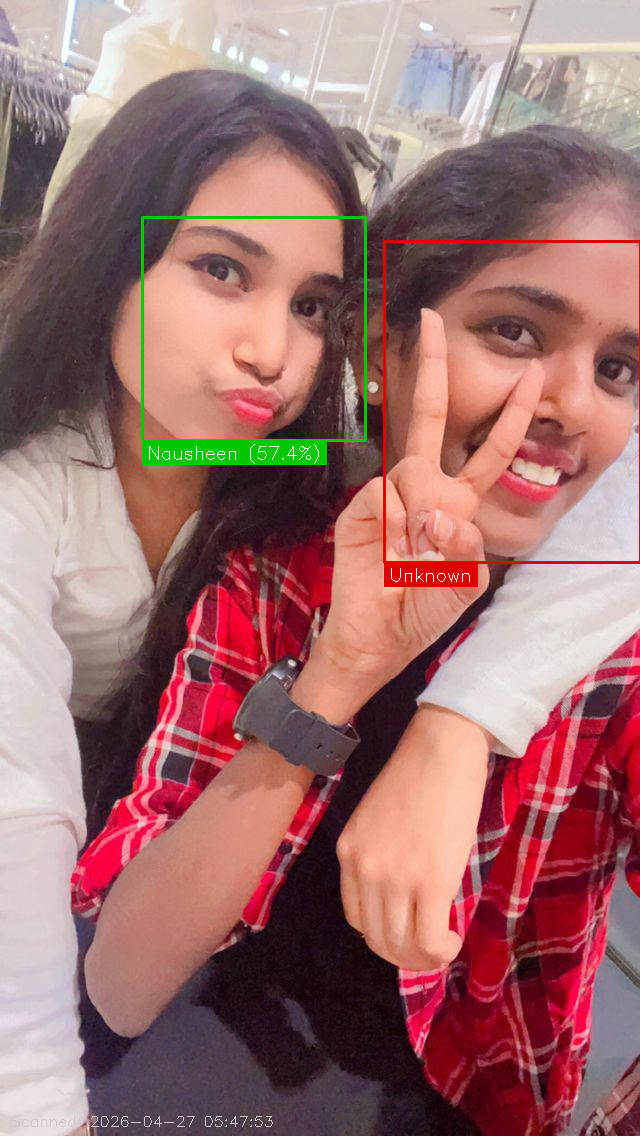


📋 Current Session Attendance:
   ✅ Nausheen — 2026-04-27 at 05:47:53


In [14]:
# ─────────────────────────────────────────────
# CELL 8: Upload & Scan a Test Image
# ─────────────────────────────────────────────
"""
Upload any image (individual or group photo) to scan for attendance.
"""

print("📤 Upload an image to scan for attendance:")
uploaded_test = files.upload()

for filename, data in uploaded_test.items():
    # Save to disk
    test_path = os.path.join("test_images", filename)
    with open(test_path, "wb") as f:
        f.write(data)

    print(f"\n🖼️  Processing: {filename}")
    annotated_img, found_names = recognize_faces_in_image(
        test_path,
        known_encodings,
        known_names,
        tolerance=0.5,
        model="hog"
    )

print("\n📋 Current Session Attendance:")
if attendance_log:
    for person, record in attendance_log.items():
        print(f"   ✅ {person} — {record['Date']} at {record['Time']}")
else:
    print("   No attendance recorded yet.")



📤 Upload multiple images for batch scanning:


Saving IMG_20231112_232636.jpg to IMG_20231112_232636.jpg
Saving IMG_20231112_232652.jpg to IMG_20231112_232652.jpg

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🖼️  Scanning: IMG_20231112_232636.jpg

👤 Faces detected: 2
   👤 Nausheen | Confidence: 62.1% | 🔁 Already Marked
   ❓ Unknown face detected at position (133, 442)


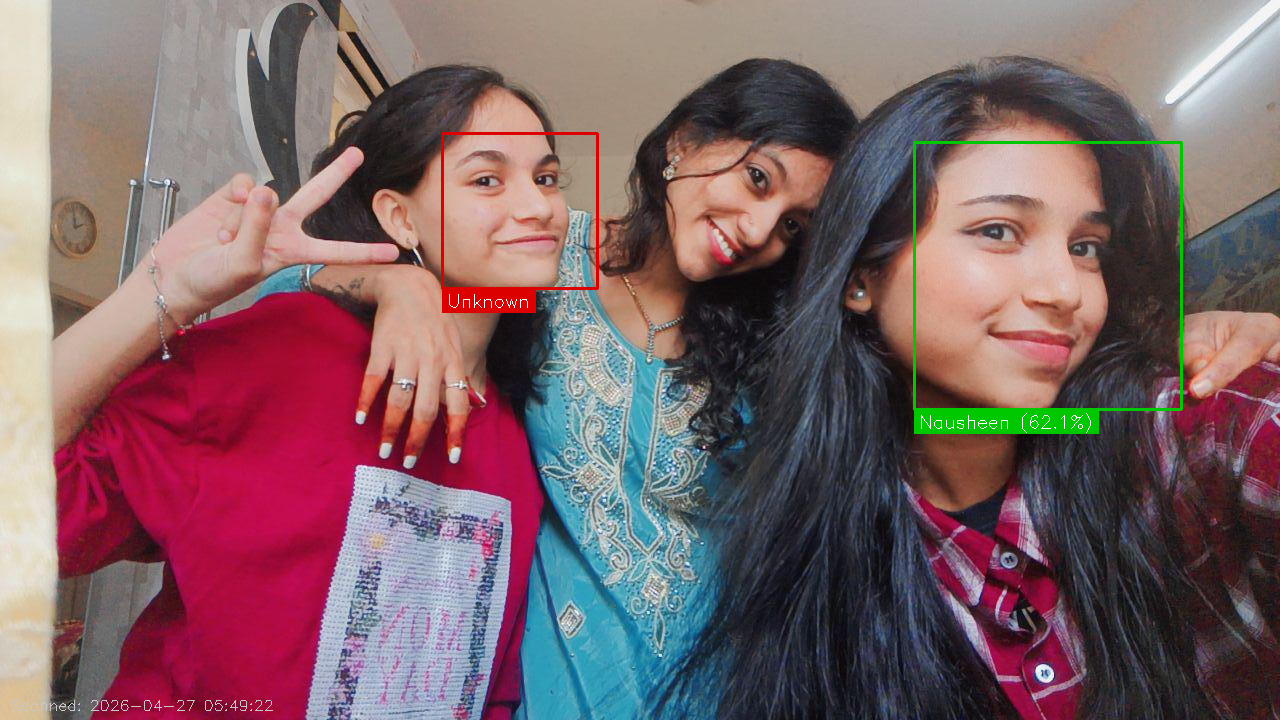


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🖼️  Scanning: IMG_20231112_232652.jpg

👤 Faces detected: 2
   👤 Nausheen | Confidence: 59.8% | 🔁 Already Marked
   ❓ Unknown face detected at position (98, 840)


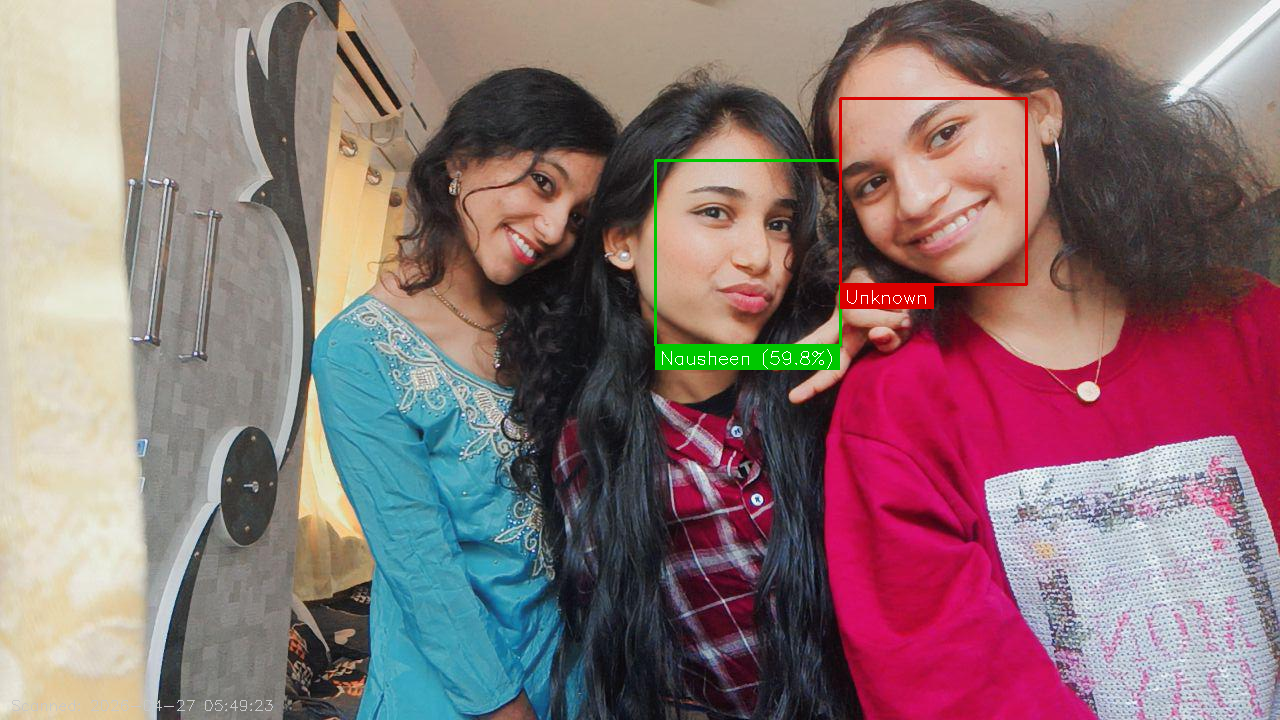



📊 FINAL BATCH ATTENDANCE SUMMARY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   ✅ Nausheen — 2026-04-27 at 05:47:53


In [15]:
# ─────────────────────────────────────────────
# CELL 9: Scan Multiple Images (Batch Mode)
# ─────────────────────────────────────────────
"""
Upload multiple images at once (e.g., classroom, meeting photos).
Attendance is accumulated across all images.
"""

print("📤 Upload multiple images for batch scanning:")
batch_uploads = files.upload()

for filename, data in batch_uploads.items():
    test_path = os.path.join("test_images", filename)
    with open(test_path, "wb") as f:
        f.write(data)

    print(f"\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
    print(f"🖼️  Scanning: {filename}")
    recognize_faces_in_image(
        test_path,
        known_encodings,
        known_names,
        tolerance=0.5,
        model="hog"
    )

print("\n\n📊 FINAL BATCH ATTENDANCE SUMMARY:")
print("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
for person, record in attendance_log.items():
    print(f"   ✅ {person} — {record['Date']} at {record['Time']}")



In [16]:
# ─────────────────────────────────────────────
# CELL 10: Save & Download Attendance CSV
# ─────────────────────────────────────────────

filepath = save_attendance_to_csv()

if filepath:
    print("\n📥 Downloading attendance CSV...")
    files.download(filepath)




💾 Attendance saved to: attendance_records/attendance_2026-04-27_05-49-46.csv


,Name,Date,Time,Status
0,Nausheen,2026-04-27,05:47:53,Present



📥 Downloading attendance CSV...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
# ─────────────────────────────────────────────
# CELL 11: View All Saved Attendance Records
# ─────────────────────────────────────────────

print("📂 All saved attendance records:\n")
csv_files = [f for f in os.listdir("attendance_records") if f.endswith(".csv")]

if not csv_files:
    print("   No records found yet.")
else:
    for csv_file in sorted(csv_files):
        print(f"\n📄 {csv_file}")
        df = pd.read_csv(os.path.join("attendance_records", csv_file))
        display(df)


📂 All saved attendance records:


📄 attendance_2026-04-27_05-49-46.csv


,Name,Date,Time,Status
0,Nausheen,2026-04-27,05:47:53,Present


In [20]:
from IPython.display import Javascript
Javascript("...")

<IPython.core.display.Javascript object>

📸 Opening webcam for live attendance capture...


<IPython.core.display.Javascript object>


🔍 Scanning webcam image...

👤 Faces detected: 1
   👤 Nausheen | Confidence: 72.1% | 🔁 Already Marked


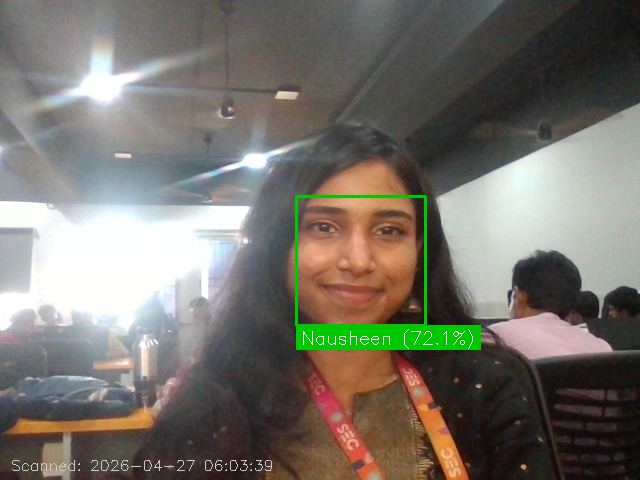


✅ Recognized in webcam: ['Nausheen']


In [36]:
# ─────────────────────────────────────────────
# CELL 13: Live Webcam Attendance (FIXED)
# ─────────────────────────────────────────────

from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def take_webcam_photo():
    js_code = '''
    async function takePhoto() {
        const video = document.createElement('video');
        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        document.body.appendChild(video);
        video.srcObject = stream;
        await video.play();

        // wait 2 seconds
        await new Promise(resolve => setTimeout(resolve, 2000));

        const canvas = document.createElement('canvas');
        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext('2d').drawImage(video, 0, 0);

        stream.getTracks().forEach(track => track.stop());
        video.remove();

        return canvas.toDataURL('image/jpeg');
    }
    '''

    # ✅ correct way
    display(Javascript(js_code))
    data = eval_js("takePhoto()")

    binary = b64decode(data.split(',')[1])
    img = np.frombuffer(binary, dtype=np.uint8)
    return cv2.imdecode(img, cv2.IMREAD_COLOR)


print("📸 Opening webcam for live attendance capture...")
webcam_image = take_webcam_photo()

print("\n🔍 Scanning webcam image...")

annotated, names = recognize_faces_in_image(
    webcam_image,
    known_encodings,
    known_names,
    tolerance=0.5,
    model="hog",
    show_output=True
)

print(f"\n✅ Recognized in webcam: {names if names else 'No faces found'}")